# `melt` do Pandas

Professor [Francisco Bustamante](https://linkedin.com/in/flsbustamante)

O método `melt` serve para transformar um DataFrame de formato largo para um formato longo. Em um DataFrame de formato largo, as colunas representam diferentes variáveis, e os dados de cada variável são mantidos separados. No formato longo, os dados são reorganizados de modo que cada linha representa uma observação individual de uma variável específica.

O método `melt` "derrete" (ou seja, transforma) colunas selecionadas em duas colunas: uma que contém o nome das variáveis e outra que contém os valores dessas variáveis. 

Use o `melt` quando:

1. **Reorganizar os dados**: Você precisa reorganizar seus dados para que cada observação seja representada por uma única linha. Isso é particularmente útil em preparação para análises que requerem um formato longo, como muitas funções de bibliotecas estatísticas e de visualização de dados.

2. **Transformar múltiplas colunas em uma única coluna**: Quando suas variáveis estão espalhadas em várias colunas e você deseja consolidá-las em uma única coluna para facilitar a manipulação e a análise.

3. **Dados com diferentes categorias e períodos**: Quando você tem dados que incluem diferentes categorias e períodos e você deseja transformar essas categorias e períodos em linhas distintas.


Contexto:

Uma empresa que realiza pesquisas de satisfação do cliente trimestralmente. Cada cliente responde a perguntas sobre sua satisfação geral, com o produto e com o serviço. As respostas são coletadas nos meses de janeiro, fevereiro e março de 2024. As informações coletadas estão organizadas em uma base de dados, onde cada linha representa um cliente e suas respostas para cada categoria de satisfação em diferentes meses.

Faça uma análise estatística das notas dos clientes considerando a categoria de satisfação e o mês.

In [1]:
import pandas as pd

BASE = "./dados/dados_satisfacao.csv"

dados = pd.read_csv(BASE)

dados

,cliente_id,satisfacao_geral_01-2024,satisfacao_geral_02-2024,satisfacao_geral_03-2024,satisfacao_produto_01-2024,satisfacao_produto_02-2024,satisfacao_produto_03-2024,satisfacao_servico_01-2024,satisfacao_servico_02-2024,satisfacao_servico_03-2024,idade,genero
0,1,4,3,4,5,4,4,3,4,4,25,F
1,2,5,2,4,4,5,4,4,2,4,35,M
2,3,3,1,3,4,3,5,3,2,5,45,F
3,4,4,4,5,3,5,5,4,5,3,28,M
4,5,4,4,4,4,3,4,3,4,4,38,F
5,6,5,2,4,4,4,5,5,4,5,48,M
6,7,3,4,5,5,4,4,4,5,4,30,F
7,8,4,4,3,4,5,3,5,4,4,40,M
8,9,5,3,4,5,4,4,4,3,5,50,F
9,10,3,4,5,4,3,5,2,3,4,32,M


In [2]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   cliente_id                  10 non-null     int64 
 1   satisfacao_geral_01-2024    10 non-null     int64 
 2   satisfacao_geral_02-2024    10 non-null     int64 
 3   satisfacao_geral_03-2024    10 non-null     int64 
 4   satisfacao_produto_01-2024  10 non-null     int64 
 5   satisfacao_produto_02-2024  10 non-null     int64 
 6   satisfacao_produto_03-2024  10 non-null     int64 
 7   satisfacao_servico_01-2024  10 non-null     int64 
 8   satisfacao_servico_02-2024  10 non-null     int64 
 9   satisfacao_servico_03-2024  10 non-null     int64 
 10  idade                       10 non-null     int64 
 11  genero                      10 non-null     object
dtypes: int64(11), object(1)
memory usage: 1.1+ KB


In [3]:
# Usando melt para transformar o DataFrame
dados_melt = pd.melt(
    dados,
    id_vars=["cliente_id", "idade", "genero"],
    value_vars=[
        "satisfacao_geral_01-2024",
        "satisfacao_geral_02-2024",
        "satisfacao_geral_03-2024",
        "satisfacao_produto_01-2024",
        "satisfacao_produto_02-2024",
        "satisfacao_produto_03-2024",
        "satisfacao_servico_01-2024",
        "satisfacao_servico_02-2024",
        "satisfacao_servico_03-2024",
    ],
    var_name="categoria_mes",
    value_name="nota",
)

dados_melt

,cliente_id,idade,genero,categoria_mes,nota
0,1,25,F,satisfacao_geral_01-2024,4
1,2,35,M,satisfacao_geral_01-2024,5
2,3,45,F,satisfacao_geral_01-2024,3
3,4,28,M,satisfacao_geral_01-2024,4
4,5,38,F,satisfacao_geral_01-2024,4
...,...,...,...,...,...
85,6,48,M,satisfacao_servico_03-2024,5
86,7,30,F,satisfacao_servico_03-2024,4
87,8,40,M,satisfacao_servico_03-2024,4
88,9,50,F,satisfacao_servico_03-2024,5


In [4]:
dados_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   cliente_id     90 non-null     int64 
 1   idade          90 non-null     int64 
 2   genero         90 non-null     object
 3   categoria_mes  90 non-null     object
 4   nota           90 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 3.6+ KB


In [5]:
# Separando 'categoria_mes' em 'categoria' e 'mes'
dados_melt[["categoria", "mes"]] = dados_melt["categoria_mes"].str.rsplit(
    "_", n=1, expand=True
)
dados_melt = dados_melt.drop(columns=["categoria_mes"])

dados_melt

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,01-2024
1,2,35,M,5,satisfacao_geral,01-2024
2,3,45,F,3,satisfacao_geral,01-2024
3,4,28,M,4,satisfacao_geral,01-2024
4,5,38,F,4,satisfacao_geral,01-2024
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,03-2024
86,7,30,F,4,satisfacao_servico,03-2024
87,8,40,M,4,satisfacao_servico,03-2024
88,9,50,F,5,satisfacao_servico,03-2024


Documentação `rsplit`: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.rsplit.html

In [6]:
dados_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   idade       90 non-null     int64 
 2   genero      90 non-null     object
 3   nota        90 non-null     int64 
 4   categoria   90 non-null     object
 5   mes         90 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.3+ KB


In [7]:
# coluna mes para datetime
dados_melt["mes"] = pd.to_datetime(dados_melt["mes"], format="%m-%Y")

dados_melt

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,2024-01-01
1,2,35,M,5,satisfacao_geral,2024-01-01
2,3,45,F,3,satisfacao_geral,2024-01-01
3,4,28,M,4,satisfacao_geral,2024-01-01
4,5,38,F,4,satisfacao_geral,2024-01-01
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,2024-03-01
86,7,30,F,4,satisfacao_servico,2024-03-01
87,8,40,M,4,satisfacao_servico,2024-03-01
88,9,50,F,5,satisfacao_servico,2024-03-01


In [8]:
# pegar apenas o mês da data
dados_melt["mes"] = dados_melt["mes"].dt.month

dados_melt

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,1
1,2,35,M,5,satisfacao_geral,1
2,3,45,F,3,satisfacao_geral,1
3,4,28,M,4,satisfacao_geral,1
4,5,38,F,4,satisfacao_geral,1
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,3
86,7,30,F,4,satisfacao_servico,3
87,8,40,M,4,satisfacao_servico,3
88,9,50,F,5,satisfacao_servico,3


In [9]:
dados_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   idade       90 non-null     int64 
 2   genero      90 non-null     object
 3   nota        90 non-null     int64 
 4   categoria   90 non-null     object
 5   mes         90 non-null     int32 
dtypes: int32(1), int64(3), object(2)
memory usage: 4.0+ KB


In [10]:
# colunas 'genero' e 'categoria' para categorias
dados_melt["genero"] = dados_melt["genero"].astype("category")
dados_melt["categoria"] = dados_melt["categoria"].astype("category")

dados_melt

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,1
1,2,35,M,5,satisfacao_geral,1
2,3,45,F,3,satisfacao_geral,1
3,4,28,M,4,satisfacao_geral,1
4,5,38,F,4,satisfacao_geral,1
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,3
86,7,30,F,4,satisfacao_servico,3
87,8,40,M,4,satisfacao_servico,3
88,9,50,F,5,satisfacao_servico,3


Vídeo sobre tipos categóricos: https://www.youtube.com/watch?v=yjCtRmc4D7Q


In [11]:
dados_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cliente_id  90 non-null     int64   
 1   idade       90 non-null     int64   
 2   genero      90 non-null     category
 3   nota        90 non-null     int64   
 4   categoria   90 non-null     category
 5   mes         90 non-null     int32   
dtypes: category(2), int32(1), int64(3)
memory usage: 3.0 KB


In [12]:
dados_melt.groupby(['categoria', 'mes'])['nota'].mean()

categoria           mes
satisfacao_geral    1      4.0
                    2      3.1
                    3      4.1
satisfacao_produto  1      4.2
                    2      4.0
                    3      4.3
satisfacao_servico  1      3.7
                    2      3.6
                    3      4.2
Name: nota, dtype: float64

In [13]:
dados_melt.groupby(['categoria', 'mes'])['nota'].agg(["min", "max", "mean"])

min  max  mean
categoria          mes                
satisfacao_geral   1      3    5   4.0
                   2      1    4   3.1
                   3      3    5   4.1
satisfacao_produto 1      3    5   4.2
                   2      3    5   4.0
                   3      3    5   4.3
satisfacao_servico 1      2    5   3.7
                   2      2    5   3.6
                   3      3    5   4.2

In [14]:
dados_melt.groupby(['categoria', 'mes'])['nota'].describe()

count  mean       std  min   25%  50%   75%  max
categoria          mes                                                  
satisfacao_geral   1     10.0   4.0  0.816497  3.0  3.25  4.0  4.75  5.0
                   2     10.0   3.1  1.100505  1.0  2.25  3.5  4.00  4.0
                   3     10.0   4.1  0.737865  3.0  4.00  4.0  4.75  5.0
satisfacao_produto 1     10.0   4.2  0.632456  3.0  4.00  4.0  4.75  5.0
                   2     10.0   4.0  0.816497  3.0  3.25  4.0  4.75  5.0
                   3     10.0   4.3  0.674949  3.0  4.00  4.0  5.00  5.0
satisfacao_servico 1     10.0   3.7  0.948683  2.0  3.00  4.0  4.00  5.0
                   2     10.0   3.6  1.074968  2.0  3.00  4.0  4.00  5.0
                   3     10.0   4.2  0.632456  3.0  4.00  4.0  4.75  5.0

<Axes: xlabel='categoria', ylabel='nota'>

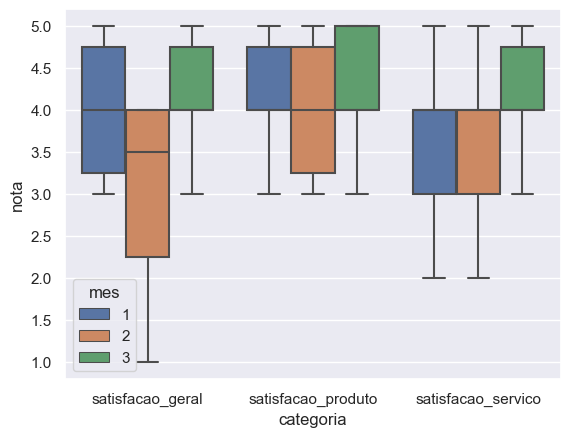

In [15]:
# boxplot das notas por categoria e mês
import seaborn as sns

sns.set_theme()

sns.boxplot(data=dados_melt, x="categoria", y="nota", hue="mes")

Veja o vídeo sobre histogramas e boxplots: https://www.youtube.com/watch?v=sLWWJc6TjWc

Outro vídeo sobre reshaping: https://www.youtube.com/watch?v=YuInXWUuuHg

## Bônus

Para quem baixou o material, vou mostrar aqui o mesmo resultado do reshape sendo feito com o `wide_to_long`, que será objeto de vídeo futuro.

Documentação: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.wide_to_long.html

In [21]:
# começando com os dados originais
import pandas as pd

BASE = "./dados/dados_satisfacao.csv"

dados = pd.read_csv(BASE)

dados

,cliente_id,satisfacao_geral_01-2024,satisfacao_geral_02-2024,satisfacao_geral_03-2024,satisfacao_produto_01-2024,satisfacao_produto_02-2024,satisfacao_produto_03-2024,satisfacao_servico_01-2024,satisfacao_servico_02-2024,satisfacao_servico_03-2024,idade,genero
0,1,4,3,4,5,4,4,3,4,4,25,F
1,2,5,2,4,4,5,4,4,2,4,35,M
2,3,3,1,3,4,3,5,3,2,5,45,F
3,4,4,4,5,3,5,5,4,5,3,28,M
4,5,4,4,4,4,3,4,3,4,4,38,F
5,6,5,2,4,4,4,5,5,4,5,48,M
6,7,3,4,5,5,4,4,4,5,4,30,F
7,8,4,4,3,4,5,3,5,4,4,40,M
8,9,5,3,4,5,4,4,4,3,5,50,F
9,10,3,4,5,4,3,5,2,3,4,32,M


In [22]:
dados_long = pd.wide_to_long(
    dados,
    stubnames=["satisfacao_geral", "satisfacao_produto", "satisfacao_servico"],
    i="cliente_id",
    j="mes",
    sep="_",
    suffix="[0-9]{2}-[0-9]{4}",
).reset_index()

dados_long

,cliente_id,mes,idade,genero,satisfacao_geral,satisfacao_produto,satisfacao_servico
0,1,01-2024,25,F,4,5,3
1,2,01-2024,35,M,5,4,4
2,3,01-2024,45,F,3,4,3
3,4,01-2024,28,M,4,3,4
4,5,01-2024,38,F,4,4,3
5,6,01-2024,48,M,5,4,5
6,7,01-2024,30,F,3,5,4
7,8,01-2024,40,M,4,4,5
8,9,01-2024,50,F,5,5,4
9,10,01-2024,32,M,3,4,2


Observe que já foi feita a separação da coluna com data, mas ainda há três colunas para categorias de satisfação. Para juntá-las, será necessário o `melt` de qualquer forma:

In [29]:
# Melt do DataFrame para ter uma única coluna de valores numéricos
dados_long_melted = dados_long.melt(
    id_vars=["cliente_id", "mes", "idade", "genero"],
    value_vars=["satisfacao_geral", "satisfacao_produto", "satisfacao_servico"],
    var_name="categoria",
    value_name="nota",
)

dados_long_melted

,cliente_id,mes,idade,genero,categoria,nota
0,1,01-2024,25,F,satisfacao_geral,4
1,2,01-2024,35,M,satisfacao_geral,5
2,3,01-2024,45,F,satisfacao_geral,3
3,4,01-2024,28,M,satisfacao_geral,4
4,5,01-2024,38,F,satisfacao_geral,4
...,...,...,...,...,...,...
85,6,03-2024,48,M,satisfacao_servico,5
86,7,03-2024,30,F,satisfacao_servico,4
87,8,03-2024,40,M,satisfacao_servico,4
88,9,03-2024,50,F,satisfacao_servico,5


Veja que o `wide_to_long` facilitou a obtenção da coluna de data, mas ainda foi necessária uma etapa de `melt`.

A partir daqui, basta fazer os mesmos tratamentos mostrados anteriormente (pegar apenas o mês da data, mudar tipos, etc).

In [30]:
dados_long_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   mes         90 non-null     object
 2   idade       90 non-null     int64 
 3   genero      90 non-null     object
 4   categoria   90 non-null     object
 5   nota        90 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 4.3+ KB


In [31]:
dados_long_melted["mes"] = pd.to_datetime(dados_long_melted["mes"], format="%m-%Y")
dados_long_melted["mes"] = dados_long_melted["mes"].dt.month

dados_long_melted["genero"] = dados_long_melted["genero"].astype("category")
dados_long_melted["categoria"] = dados_long_melted["categoria"].astype("category")

dados_long_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cliente_id  90 non-null     int64   
 1   mes         90 non-null     int32   
 2   idade       90 non-null     int64   
 3   genero      90 non-null     category
 4   categoria   90 non-null     category
 5   nota        90 non-null     int64   
dtypes: category(2), int32(1), int64(3)
memory usage: 3.0 KB


<Axes: xlabel='categoria', ylabel='nota'>

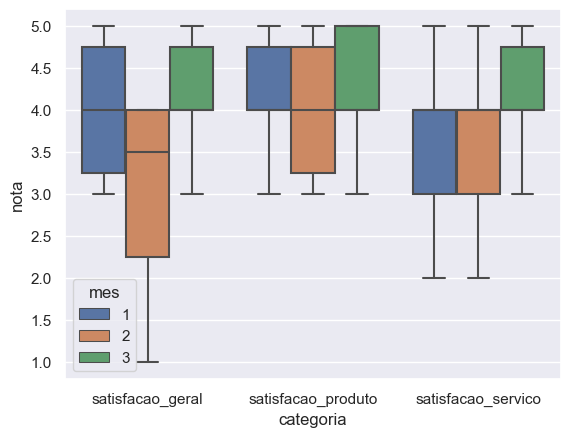

In [32]:
import seaborn as sns

sns.set_theme()

sns.boxplot(data=dados_long_melted, x="categoria", y="nota", hue="mes")